# Customer Segmentation & Loyalty Analysis

## Objective

This notebook prepares the customer-level analytical dataset for:

1. Data quality assessment
2. Customer behavioral feature engineering
3. Competing loyalty definitions
4. Customer value segmentation
5. Loyalty-definition validation
6. Ideal customer profiling
7. SQL and Power BI downstream analysis

## Important data limitation

The source dataset contains one record per customer rather than a transaction-level history.

Therefore:

- `purchase_amount_usd` is treated as the customer's observed/current purchase value.
- `previous_purchases` is treated as historical purchase depth.
- `frequency_of_purchases` is converted into an estimated annual purchase cadence.
- Lifetime revenue is NOT calculated.
- True churn is NOT calculated because there is no timestamp/churn label.
- A single observed discount/promo use is NOT called "true promo dependency".

These distinctions are intentionally preserved to avoid overstating what the dataset can support.

## Imports

In [1]:
# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Configuration

In [6]:
# =========================================================
# PROJECT CONFIGURATION
# =========================================================

# Project structure:
#
# project_2/
# ├── Dataset.csv
# ├── project_2_final.ipynb
# └── outputs/

DATA_PATH = Path("Dataset.csv")

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Data path: C:\Users\VARSHIKA MUTHA\Desktop\project_2\Dataset.csv
Output directory: C:\Users\VARSHIKA MUTHA\Desktop\project_2\output


## Load Dataset

In [7]:
# =========================================================
# LOAD DATA
# =========================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Please update DATA_PATH in the configuration cell."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

display(df.head())

Dataset loaded successfully.
Rows: 3,900
Columns: 18


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.10,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.10,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.10,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.50,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.70,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## Column Inventory

In [8]:
# =========================================================
# COLUMN INVENTORY
# =========================================================

column_inventory = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).values,
    "unique_values": df.nunique(dropna=True).values
})

column_inventory = column_inventory.sort_values(
    by="missing_pct",
    ascending=False
)

display(column_inventory)

,column,dtype,missing_count,missing_pct,unique_values
Review Rating,Review Rating,float64,37,0.95,26
Customer ID,Customer ID,int64,0,0.00,3900
Age,Age,int64,0,0.00,53
Payment Method,Payment Method,str,0,0.00,6
Previous Purchases,Previous Purchases,int64,0,0.00,50
Promo Code Used,Promo Code Used,str,0,0.00,2
Discount Applied,Discount Applied,str,0,0.00,2
Shipping Type,Shipping Type,str,0,0.00,6
Subscription Status,Subscription Status,str,0,0.00,2
Season,Season,str,0,0.00,4


## Standardize column names

In [9]:
# =========================================================
# STANDARDIZE COLUMN NAMES
# =========================================================

original_columns = df.columns.tolist()

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
      .str.replace(r"[^\w]+", "_", regex=True)
      .str.replace(r"_+", "_", regex=True)
      .str.strip("_")
)

column_mapping = pd.DataFrame({
    "original": original_columns,
    "standardized": df.columns
})

display(column_mapping)

,original,standardized
0,Customer ID,customer_id
1,Age,age
2,Gender,gender
3,Item Purchased,item_purchased
4,Category,category
5,Purchase Amount (USD),purchase_amount_usd
6,Location,location
7,Size,size
8,Color,color
9,Season,season


## Validate required columns

In [10]:
# =========================================================
# REQUIRED COLUMN VALIDATION
# =========================================================

required_columns = [
    "customer_id",
    "purchase_amount_usd",
    "previous_purchases",
    "frequency_of_purchases",
    "discount_applied",
    "promo_code_used",
    "review_rating",
    "age",
    "gender",
    "location",
    "subscription_status",
    "payment_method",
    "shipping_type",
    "category",
    "season"
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

if missing_required:
    print("Missing required columns:")
    for col in missing_required:
        print(" -", col)
    
    print("\nAvailable columns:")
    print(df.columns.tolist())
    
    raise ValueError(
        "Required columns are missing. "
        "Check the standardized column names above."
    )

print("All required columns are present.")

All required columns are present.


## Basic dataset diagnostic

In [11]:
# =========================================================
# DATASET GRAIN DIAGNOSTICS
# =========================================================

n_rows = len(df)
n_customers = df["customer_id"].nunique()
duplicate_customer_rows = df["customer_id"].duplicated().sum()

print(f"Total rows: {n_rows:,}")
print(f"Unique customers: {n_customers:,}")
print(f"Duplicate customer rows: {duplicate_customer_rows:,}")

print("\nRows per customer:")
rows_per_customer = (
    df.groupby("customer_id")
      .size()
      .value_counts()
      .sort_index()
)

display(rows_per_customer.to_frame("number_of_customers"))

Total rows: 3,900
Unique customers: 3,900
Duplicate customer rows: 0

Rows per customer:


,number_of_customers
1,3900


## Establish data again

In [12]:
# =========================================================
# DATA GRAIN
# =========================================================

if n_rows == n_customers:
    DATA_GRAIN = "one row per customer"
else:
    DATA_GRAIN = "multiple rows may exist per customer"

print("Detected data grain:", DATA_GRAIN)

if DATA_GRAIN == "one row per customer":
    print(
        "\nIMPORTANT:\n"
        "The dataset is customer-level, not transaction-level.\n"
        "Do not interpret row counts as purchase frequency."
    )
else:
    print(
        "\nMultiple records exist for some customers.\n"
        "Customer-level aggregation will therefore be applied."
    )

Detected data grain: one row per customer

IMPORTANT:
The dataset is customer-level, not transaction-level.
Do not interpret row counts as purchase frequency.


## Dublicate row check

In [13]:
# =========================================================
# DUPLICATE CHECK
# =========================================================

duplicate_rows = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_rows:,}")

if duplicate_rows > 0:
    print("Duplicate rows detected.")
else:
    print("No exact duplicate rows detected.")

Exact duplicate rows: 0
No exact duplicate rows detected.


## Missing value

In [14]:
# =========================================================
# MISSING VALUES
# =========================================================

missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_pct",
    ascending=False
)

display(missing_summary)

,missing_count,missing_pct
review_rating,37,0.95


## Numeric diagnostics

In [16]:
# =========================================================
# NUMERIC DIAGNOSTICS
# =========================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_summary = df[numeric_columns].describe().T

numeric_summary["missing"] = df[numeric_columns].isna().sum()

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing
customer_id,"3,900.00","1,950.50","1,125.98",1.00,975.75,"1,950.50","2,925.25","3,900.00",0
age,"3,900.00",44.07,15.21,18.00,31.00,44.00,57.00,70.00,0
purchase_amount_usd,"3,900.00",59.76,23.69,20.00,39.00,60.00,81.00,100.00,0
review_rating,"3,863.00",3.75,0.72,2.50,3.10,3.80,4.40,5.00,37
previous_purchases,"3,900.00",25.35,14.45,1.00,13.00,25.00,38.00,50.00,0


## Categorical diagnostics

In [17]:
# =========================================================
# CATEGORICAL DIAGNOSTICS
# =========================================================

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in categorical_columns:
    print("=" * 70)
    print(f"{col}")
    print("=" * 70)
    display(
        df[col]
        .value_counts(dropna=False)
        .to_frame("count")
    )

gender


,count
gender,
Male,2652
Female,1248


item_purchased


,count
item_purchased,
Blouse,171
Pants,171
Jewelry,171
Shirt,169
Dress,166
Sweater,164
Jacket,163
Coat,161
Sunglasses,161


category


...

,count
promo_code_used,
No,2223
Yes,1677


payment_method


,count
payment_method,
PayPal,677
Credit Card,671
Cash,670
Debit Card,636
Venmo,634
Bank Transfer,612


frequency_of_purchases


,count
frequency_of_purchases,
Every 3 Months,584
Annually,572
Quarterly,563
Monthly,553
Bi-Weekly,547
Fortnightly,542
Weekly,539


## Standardize Yes/No fields

In [18]:
# =========================================================
# STANDARDIZE YES/NO FIELDS
# =========================================================

yes_no_columns = [
    "discount_applied",
    "promo_code_used",
    "subscription_status"
]

for col in yes_no_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.title()
    )

yes_no_map = {
    "Yes": 1,
    "No": 0
}

for col in yes_no_columns:
    df[f"{col}_flag"] = df[col].map(yes_no_map)

for col in yes_no_columns:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False))


discount_applied


discount_applied
No     2223
Yes    1677
Name: count, dtype: int64[pyarrow]


promo_code_used


promo_code_used
No     2223
Yes    1677
Name: count, dtype: int64[pyarrow]


subscription_status


subscription_status
No     2847
Yes    1053
Name: count, dtype: int64[pyarrow]

## Numerica type conversion

In [19]:
# =========================================================
# NUMERIC TYPE CONVERSION
# =========================================================

numeric_expected = [
    "purchase_amount_usd",
    "previous_purchases",
    "review_rating",
    "age"
]

for col in numeric_expected:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

display(df[numeric_expected].dtypes)

purchase_amount_usd      int64
previous_purchases       int64
review_rating          float64
age                      int64
dtype: object

## Validate numeric ranges

In [20]:
# =========================================================
# RANGE VALIDATION
# =========================================================

range_checks = {
    "purchase_amount_usd": (0, np.inf),
    "previous_purchases": (0, np.inf),
    "review_rating": (1, 5),
    "age": (0, 120)
}

range_issues = {}

for col, (lower, upper) in range_checks.items():
    invalid = (
        (df[col] < lower) |
        (df[col] > upper)
    )

    invalid_count = invalid.sum()

    range_issues[col] = invalid_count

    print(
        f"{col}: {invalid_count:,} invalid values"
    )

if any(v > 0 for v in range_issues.values()):
    print("\nWARNING: Review these values before proceeding.")
else:
    print("\nAll numeric range checks passed.")

purchase_amount_usd: 0 invalid values
previous_purchases: 0 invalid values
review_rating: 0 invalid values
age: 0 invalid values

All numeric range checks passed.


## Handle impossible numeric values

In [21]:
# =========================================================
# HANDLE INVALID NUMERIC VALUES
# =========================================================

for col, (lower, upper) in range_checks.items():
    invalid = (
        (df[col] < lower) |
        (df[col] > upper)
    )
    
    if invalid.any():
        df.loc[invalid, col] = np.nan

print("Invalid numeric values have been converted to NaN.")

Invalid numeric values have been converted to NaN.


## Review missingness

In [22]:
# =========================================================
# REVIEW MISSINGNESS FLAG
# =========================================================

df["rating_missing"] = (
    df["review_rating"].isna().astype(int)
)

print(
    f"Customers without a review rating: "
    f"{df['rating_missing'].sum():,}"
)

Customers without a review rating: 37


## Promo/discount consistency check

In [23]:
# =========================================================
# PROMO VS DISCOUNT CONSISTENCY
# =========================================================

promo_discount_crosstab = pd.crosstab(
    df["discount_applied"],
    df["promo_code_used"],
    dropna=False
)

display(promo_discount_crosstab)

promo_code_used,No,Yes
discount_applied,,
No,2223,0
Yes,0,1677


## Measure whether promo and discount are duplicates

In [24]:
# =========================================================
# CHECK WHETHER PROMO AND DISCOUNT ARE DUPLICATES
# =========================================================

valid_promo_rows = df[
    df["discount_applied_flag"].notna() &
    df["promo_code_used_flag"].notna()
].copy()

if len(valid_promo_rows) > 0:
    promo_discount_match_rate = (
        valid_promo_rows["discount_applied_flag"]
        == valid_promo_rows["promo_code_used_flag"]
    ).mean()
else:
    promo_discount_match_rate = np.nan

print(
    f"Promo/discount agreement rate: "
    f"{promo_discount_match_rate:.2%}"
)

Promo/discount agreement rate: 100.00%


## Create a single promotion-use variable

In [25]:
# =========================================================
# CONSOLIDATED PROMOTION SIGNAL
# =========================================================

if promo_discount_match_rate >= 0.99:
    print(
        "Promo code usage and discount application are "
        "effectively identical in this dataset."
    )
    
    df["promo_usage"] = df["discount_applied_flag"]
    
else:
    print(
        "Promo and discount variables differ materially. "
        "Keeping them separately for diagnostic purposes."
    )
    
    # Conservative approach:
    # treat either as promotion usage.
    df["promo_usage"] = (
        df[
            [
                "discount_applied_flag",
                "promo_code_used_flag"
            ]
        ]
        .max(axis=1, skipna=True)
    )

display(
    df["promo_usage"]
    .value_counts(dropna=False)
    .to_frame("count")
)

Promo code usage and discount application are effectively identical in this dataset.


,count
promo_usage,
0,2223
1,1677


## Purchase frequency mapping

In [26]:
# =========================================================
# PURCHASE FREQUENCY -> ESTIMATED ANNUAL CADENCE
# =========================================================

frequency_map = {
    "Weekly": 52,
    "Fortnightly": 26,
    "Bi-Weekly": 26,
    "Biweekly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Every 3 Months": 4,
    "Annually": 1,
    "Annual": 1
}

df["estimated_annual_frequency"] = (
    df["frequency_of_purchases"]
    .astype("string")
    .str.strip()
    .map(frequency_map)
)

frequency_check = (
    df[
        [
            "frequency_of_purchases",
            "estimated_annual_frequency"
        ]
    ]
    .drop_duplicates()
    .sort_values("frequency_of_purchases")
)

display(frequency_check)

,frequency_of_purchases,estimated_annual_frequency
4,Annually,1
10,Bi-Weekly,26
20,Every 3 Months,4
0,Fortnightly,26
15,Monthly,12
6,Quarterly,4
2,Weekly,52


## Detect unmapped frequency labels

In [27]:
# =========================================================
# UNMAPPED FREQUENCY LABELS
# =========================================================

unmapped_frequency = (
    df.loc[
        df["estimated_annual_frequency"].isna(),
        "frequency_of_purchases"
    ]
    .value_counts(dropna=False)
)

if len(unmapped_frequency) > 0:
    print("WARNING: Unmapped frequency values found:")
    display(unmapped_frequency.to_frame("count"))
else:
    print("All purchase-frequency values successfully mapped.")

All purchase-frequency values successfully mapped.


## Interpretation Note

In [28]:
# =========================================================
# INTERPRETATION NOTE
# =========================================================

print(
    """
INTERPRETATION NOTE

estimated_annual_frequency is an estimated purchase cadence
derived from the customer's stated frequency category.

It is NOT calculated from transaction timestamps.

Therefore it should not be described as observed historical
purchase frequency.
"""
)


INTERPRETATION NOTE

estimated_annual_frequency is an estimated purchase cadence
derived from the customer's stated frequency category.

It is NOT calculated from transaction timestamps.

Therefore it should not be described as observed historical
purchase frequency.



## Current purchase value

In [29]:
# =========================================================
# CURRENT / OBSERVED PURCHASE VALUE
# =========================================================

df["current_order_value"] = df["purchase_amount_usd"]

print(
    "Current order value summary:"
)

display(
    df["current_order_value"]
    .describe()
    .to_frame("current_order_value")
)

Current order value summary:


,current_order_value
count,"3,900.00"
mean,59.76
std,23.69
min,20.00
25%,39.00
50%,60.00
75%,81.00
max,100.00


## Important distinction from lifetime spend

In [30]:
# =========================================================
# LIFETIME SPEND WARNING
# =========================================================

print(
    """
The dataset does not contain transaction-level historical
revenue for each customer.

Therefore:

current_order_value != lifetime_spend
current_order_value != total_customer_revenue

The notebook will NOT create a fake lifetime-spend metric.
"""
)


The dataset does not contain transaction-level historical
revenue for each customer.

Therefore:

current_order_value != lifetime_spend
current_order_value != total_customer_revenue

The notebook will NOT create a fake lifetime-spend metric.



## Review imputation

In [31]:
# =========================================================
# REVIEW IMPUTATION
# =========================================================

review_median = df["review_rating"].median()

df["review_rating_filled"] = (
    df["review_rating"]
    .fillna(review_median)
)

print(
    f"Median review rating used only for score calculations: "
    f"{review_median:.2f}"
)

Median review rating used only for score calculations: 3.80


## Customer-level aggregation

Even though the dataset currently appears to be one row/customer, this aggregation makes the analytical layer robust.

In [32]:
# =========================================================
# CUSTOMER-LEVEL ANALYTICAL TABLE
# =========================================================

aggregation = {
    "current_order_value": ("current_order_value", "first"),
    "previous_purchases": ("previous_purchases", "first"),
    "estimated_annual_frequency": (
        "estimated_annual_frequency",
        "first"
    ),
    "frequency_label": (
        "frequency_of_purchases",
        "first"
    ),

    "promo_usage": ("promo_usage", "first"),

    "average_rating": (
        "review_rating_filled",
        "mean"
    ),

    "rating_missing": (
        "rating_missing",
        "max"
    ),

    "age": ("age", "first"),
    "gender": ("gender", "first"),
    "location": ("location", "first"),

    "subscription_status": (
        "subscription_status",
        "first"
    ),

    "subscription_flag": (
        "subscription_status_flag",
        "first"
    ),

    "payment_method": (
        "payment_method",
        "first"
    ),

    "shipping_type": (
        "shipping_type",
        "first"
    ),

    "category": ("category", "first"),
    "season": ("season", "first")
}

customer_metrics = (
    df.groupby("customer_id")
      .agg(**aggregation)
      .reset_index()
)

print(
    f"Customer-level dataset created: "
    f"{len(customer_metrics):,} customers"
)

display(customer_metrics.head())

Customer-level dataset created: 3,900 customers


,customer_id,current_order_value,previous_purchases,estimated_annual_frequency,frequency_label,promo_usage,average_rating,rating_missing,age,gender,location,subscription_status,subscription_flag,payment_method,shipping_type,category,season
0,1,53,14,26,Fortnightly,1,3.10,0,55,Male,Kentucky,Yes,1,Venmo,Express,Clothing,Winter
1,2,64,2,26,Fortnightly,1,3.10,0,19,Male,Maine,Yes,1,Cash,Express,Clothing,Winter
2,3,73,23,52,Weekly,1,3.10,0,50,Male,Massachusetts,Yes,1,Credit Card,Free Shipping,Clothing,Spring
3,4,90,49,52,Weekly,1,3.50,0,21,Male,Rhode Island,Yes,1,PayPal,Next Day Air,Footwear,Spring
4,5,49,31,1,Annually,1,2.70,0,45,Male,Oregon,Yes,1,PayPal,Free Shipping,Clothing,Spring


## Customer-level grain validation

In [33]:
# =========================================================
# CUSTOMER-LEVEL GRAIN VALIDATION
# =========================================================

assert (
    customer_metrics["customer_id"].nunique()
    == len(customer_metrics)
)

print("Customer-level uniqueness check passed.")

Customer-level uniqueness check passed.


## Known purchase depth

In [34]:
# =========================================================
# KNOWN PURCHASE DEPTH
# =========================================================

customer_metrics["known_purchase_count"] = (
    customer_metrics["previous_purchases"] + 1
)

customer_metrics["previous_purchase_depth_score"] = (
    customer_metrics["previous_purchases"]
    .rank(pct=True)
)

display(
    customer_metrics[
        [
            "customer_id",
            "previous_purchases",
            "known_purchase_count"
        ]
    ].head()
)

,customer_id,previous_purchases,known_purchase_count
0,1,14,15
1,2,2,3
2,3,23,24
3,4,49,50
4,5,31,32


## Percentile scoring helper

In [35]:
# =========================================================
# PERCENTILE SCORE FUNCTION
# =========================================================

def percentile_score(series):
    """
    Convert a numeric variable to percentile scores between 0 and 1.
    Missing values remain missing.
    """
    return series.rank(
        method="average",
        pct=True
    )

## Create behavioral scores

In [36]:
# =========================================================
# BEHAVIORAL SCORES
# =========================================================

customer_metrics["history_score"] = percentile_score(
    customer_metrics["previous_purchases"]
)

customer_metrics["frequency_score"] = percentile_score(
    customer_metrics["estimated_annual_frequency"]
)

customer_metrics["value_score"] = percentile_score(
    customer_metrics["current_order_value"]
)

customer_metrics["satisfaction_score"] = percentile_score(
    customer_metrics["average_rating"]
)

# No promotion observed = greater promotion independence
customer_metrics["promo_independence_score"] = (
    1 - customer_metrics["promo_usage"]
)

display(
    customer_metrics[
        [
            "customer_id",
            "history_score",
            "frequency_score",
            "value_score",
            "satisfaction_score",
            "promo_independence_score"
        ]
    ].head()
)

,customer_id,history_score,frequency_score,value_score,satisfaction_score,promo_independence_score
0,1,0.27,0.72,0.42,0.24,0
1,2,0.03,0.72,0.55,0.24,0
2,3,0.45,0.93,0.66,0.24,0
3,4,0.97,0.93,0.87,0.40,0
4,5,0.62,0.07,0.37,0.08,0


## Satisfaction bands

In [37]:
# =========================================================
# SATISFACTION BANDS
# =========================================================

customer_metrics["satisfaction_band"] = pd.cut(
    customer_metrics["average_rating"],
    bins=[0, 3, 4, 5],
    labels=[
        "Low",
        "Moderate",
        "High"
    ],
    include_lowest=True
)

display(
    customer_metrics["satisfaction_band"]
    .value_counts(dropna=False)
    .to_frame("customers")
)

,customers
satisfaction_band,
Moderate,1605
High,1453
Low,842


## Loyalty Definition 1
Behavioral loyalty

This definition emphasizes repeat behavior and purchase cadence.

In [38]:
# =========================================================
# LOYALTY DEFINITION 1
# BEHAVIORAL LOYALTY
# =========================================================

customer_metrics["loyalty_score_1"] = (
    customer_metrics["history_score"] * 0.40
    +
    customer_metrics["frequency_score"] * 0.40
    +
    customer_metrics["promo_independence_score"] * 0.20
)

print(
    "Definition 1 = "
    "40% purchase history + "
    "40% estimated cadence + "
    "20% promotion independence"
)

Definition 1 = 40% purchase history + 40% estimated cadence + 20% promotion independence


## Loyalty Definition 2
Behavioral + satisfaction loyalty

In [39]:
# =========================================================
# LOYALTY DEFINITION 2
# BEHAVIOR + SATISFACTION
# =========================================================

customer_metrics["loyalty_score_2"] = (
    customer_metrics["history_score"] * 0.30
    +
    customer_metrics["frequency_score"] * 0.25
    +
    customer_metrics["satisfaction_score"] * 0.25
    +
    customer_metrics["promo_independence_score"] * 0.20
)

print(
    "Definition 2 = "
    "30% purchase history + "
    "25% estimated cadence + "
    "25% satisfaction + "
    "20% promotion independence"
)

Definition 2 = 30% purchase history + 25% estimated cadence + 25% satisfaction + 20% promotion independence


## Create loyalty segments

Use quantiles rather than arbitrary fixed thresholds.

In [40]:
# =========================================================
# LOYALTY SEGMENTS
# =========================================================

customer_metrics["loyalty_segment_1"] = pd.qcut(
    customer_metrics["loyalty_score_1"],
    q=3,
    labels=[
        "Low Loyalty",
        "Medium Loyalty",
        "High Loyalty"
    ],
    duplicates="drop"
)

customer_metrics["loyalty_segment_2"] = pd.qcut(
    customer_metrics["loyalty_score_2"],
    q=3,
    labels=[
        "Low Loyalty",
        "Medium Loyalty",
        "High Loyalty"
    ],
    duplicates="drop"
)

print("Definition 1:")
display(
    customer_metrics["loyalty_segment_1"]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

print("Definition 2:")
display(
    customer_metrics["loyalty_segment_2"]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

Definition 1:


,customers
loyalty_segment_1,
Low Loyalty,1301
Medium Loyalty,1302
High Loyalty,1297


Definition 2:


,customers
loyalty_segment_2,
Low Loyalty,1300
Medium Loyalty,1300
High Loyalty,1300


## Value segmentation

We explicitly use current observed order value rather than falsely calling it lifetime value.

In [41]:
# =========================================================
# VALUE SEGMENT
# =========================================================

customer_metrics["value_segment"] = pd.qcut(
    customer_metrics["value_score"],
    q=3,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ],
    duplicates="drop"
)

display(
    customer_metrics["value_segment"]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

,customers
value_segment,
Low Value,1300
Medium Value,1303
High Value,1297


## Promotion classification

In [42]:
# =========================================================
# PROMOTION CLASSIFICATION
# =========================================================

customer_metrics["promo_segment"] = np.select(
    [
        customer_metrics["promo_usage"].eq(0),
        customer_metrics["promo_usage"].eq(1)
    ],
    [
        "No Promo Used",
        "Promo Used"
    ],
    default="Unknown"
)

display(
    customer_metrics["promo_segment"]
    .value_counts(dropna=False)
    .to_frame("customers")
)

,customers
promo_segment,
No Promo Used,2223
Promo Used,1677


## Preferred category with tie handling

In [43]:
# =========================================================
# PREFERRED CATEGORY WITH TIE HANDLING
# =========================================================

category_counts = (
    df.groupby(
        ["customer_id", "category"]
    )
    .size()
    .reset_index(name="category_observations")
)

category_counts["max_observations"] = (
    category_counts
    .groupby("customer_id")["category_observations"]
    .transform("max")
)

preferred_categories = category_counts[
    category_counts["category_observations"]
    ==
    category_counts["max_observations"]
].copy()

preferred_category_summary = (
    preferred_categories
    .groupby("customer_id")["category"]
    .agg(lambda x: " | ".join(sorted(set(x))))
    .reset_index(name="preferred_category")
)

customer_metrics = customer_metrics.merge(
    preferred_category_summary,
    on="customer_id",
    how="left"
)

display(
    customer_metrics[
        ["customer_id", "preferred_category"]
    ].head()
)

,customer_id,preferred_category
0,1,Clothing
1,2,Clothing
2,3,Clothing
3,4,Footwear
4,5,Clothing


## Preferred season with tie handling

In [44]:
# =========================================================
# PREFERRED SEASON WITH TIE HANDLING
# =========================================================

season_counts = (
    df.groupby(
        ["customer_id", "season"]
    )
    .size()
    .reset_index(name="season_observations")
)

season_counts["max_observations"] = (
    season_counts
    .groupby("customer_id")["season_observations"]
    .transform("max")
)

preferred_seasons = season_counts[
    season_counts["season_observations"]
    ==
    season_counts["max_observations"]
].copy()

preferred_season_summary = (
    preferred_seasons
    .groupby("customer_id")["season"]
    .agg(lambda x: " | ".join(sorted(set(x))))
    .reset_index(name="preferred_season")
)

customer_metrics = customer_metrics.merge(
    preferred_season_summary,
    on="customer_id",
    how="left"
)

display(
    customer_metrics[
        ["customer_id", "preferred_season"]
    ].head()
)

,customer_id,preferred_season
0,1,Winter
1,2,Winter
2,3,Spring
3,4,Spring
4,5,Spring


## Validate preferred-category merge

In [45]:
# =========================================================
# VALIDATE PREFERRED ATTRIBUTE MERGES
# =========================================================

assert customer_metrics["customer_id"].nunique() == len(
    customer_metrics
)

print(
    "Customer uniqueness preserved after category/season merges."
)

Customer uniqueness preserved after category/season merges.


## Loyalty comparison table

In [46]:
# =========================================================
# LOYALTY DEFINITION COMPARISON
# =========================================================

def loyalty_summary(segment_column):

    summary = (
        customer_metrics
        .groupby(segment_column, observed=True)
        .agg(
            customers=("customer_id", "nunique"),
            avg_current_order_value=(
                "current_order_value",
                "mean"
            ),
            avg_previous_purchases=(
                "previous_purchases",
                "mean"
            ),
            avg_annual_frequency=(
                "estimated_annual_frequency",
                "mean"
            ),
            avg_rating=(
                "average_rating",
                "mean"
            ),
            promo_usage_rate=(
                "promo_usage",
                "mean"
            ),
            subscription_rate=(
                "subscription_flag",
                "mean"
            )
        )
        .reset_index()
    )

    summary["promo_usage_rate"] *= 100
    summary["subscription_rate"] *= 100

    return summary


definition_1_summary = loyalty_summary(
    "loyalty_segment_1"
)

definition_2_summary = loyalty_summary(
    "loyalty_segment_2"
)

print("LOYALTY DEFINITION 1")
display(definition_1_summary)

print("LOYALTY DEFINITION 2")
display(definition_2_summary)

LOYALTY DEFINITION 1


,loyalty_segment_1,customers,avg_current_order_value,avg_previous_purchases,avg_annual_frequency,avg_rating,promo_usage_rate,subscription_rate
0,Low Loyalty,1301,59.46,15.73,7.39,3.76,71.25,43.50
1,Medium Loyalty,1302,59.84,24.74,17.21,3.73,41.40,27.19
2,High Loyalty,1297,59.99,35.62,27.85,3.77,16.27,10.25


LOYALTY DEFINITION 2


,loyalty_segment_2,customers,avg_current_order_value,avg_previous_purchases,avg_annual_frequency,avg_rating,promo_usage_rate,subscription_rate
0,Low Loyalty,1300,59.07,17.53,10.27,3.44,78.38,48.00
1,Medium Loyalty,1300,60.29,24.77,17.31,3.69,39.00,25.00
2,High Loyalty,1300,59.93,33.75,24.84,4.12,11.62,8.00


## Validate definitions without circularity

The key improvement here is that we don't simply correlate loyalty with the same variable that created the score.

In [47]:
# =========================================================
# DEFINITION VALIDATION
# =========================================================

validation_metrics = [
    "previous_purchases",
    "estimated_annual_frequency",
    "average_rating",
    "promo_usage",
    "subscription_flag"
]

def validate_loyalty(segment_column):
    
    result = (
        customer_metrics
        .groupby(segment_column, observed=True)[validation_metrics]
        .mean()
    )
    
    return result


validation_1 = validate_loyalty(
    "loyalty_segment_1"
)

validation_2 = validate_loyalty(
    "loyalty_segment_2"
)

print("Definition 1 validation:")
display(validation_1)

print("Definition 2 validation:")
display(validation_2)

Definition 1 validation:


,previous_purchases,estimated_annual_frequency,average_rating,promo_usage,subscription_flag
loyalty_segment_1,,,,,
Low Loyalty,15.73,7.39,3.76,0.71,0.44
Medium Loyalty,24.74,17.21,3.73,0.41,0.27
High Loyalty,35.62,27.85,3.77,0.16,0.10


Definition 2 validation:


,previous_purchases,estimated_annual_frequency,average_rating,promo_usage,subscription_flag
loyalty_segment_2,,,,,
Low Loyalty,17.53,10.27,3.44,0.78,0.48
Medium Loyalty,24.77,17.31,3.69,0.39,0.25
High Loyalty,33.75,24.84,4.12,0.12,0.08


## Check monotonicity
A good loyalty definition should generally move logically across Low → Medium → High.

In [48]:
# =========================================================
# MONOTONICITY CHECK
# =========================================================

loyalty_order = [
    "Low Loyalty",
    "Medium Loyalty",
    "High Loyalty"
]

def monotonicity_report(
    segment_column,
    metrics
):
    
    grouped = (
        customer_metrics
        .groupby(segment_column, observed=True)[metrics]
        .mean()
        .reindex(loyalty_order)
    )
    
    results = {}
    
    for metric in metrics:
        values = grouped[metric].dropna().values
        
        if len(values) < 3:
            results[metric] = "Insufficient data"
            continue
        
        increasing = np.all(np.diff(values) >= 0)
        decreasing = np.all(np.diff(values) <= 0)
        
        if increasing:
            results[metric] = "Increasing"
        elif decreasing:
            results[metric] = "Decreasing"
        else:
            results[metric] = "Non-monotonic"
    
    return pd.Series(results, name="pattern")


monotonicity_1 = monotonicity_report(
    "loyalty_segment_1",
    validation_metrics
)

monotonicity_2 = monotonicity_report(
    "loyalty_segment_2",
    validation_metrics
)

print("Definition 1:")
display(monotonicity_1.to_frame())

print("Definition 2:")
display(monotonicity_2.to_frame())

Definition 1:


,pattern
previous_purchases,Increasing
estimated_annual_frequency,Increasing
average_rating,Non-monotonic
promo_usage,Decreasing
subscription_flag,Decreasing


Definition 2:


,pattern
previous_purchases,Increasing
estimated_annual_frequency,Increasing
average_rating,Increasing
promo_usage,Decreasing
subscription_flag,Decreasing


## Compare high vs low loyalty

In [49]:
# =========================================================
# HIGH VS LOW LOYALTY COMPARISON
# =========================================================

def high_low_comparison(segment_column):

    grouped = (
        customer_metrics
        .groupby(segment_column, observed=True)[
            validation_metrics
        ]
        .mean()
        .reindex(
            [
                "Low Loyalty",
                "High Loyalty"
            ]
        )
    )

    high = grouped.loc["High Loyalty"]
    low = grouped.loc["Low Loyalty"]

    comparison = pd.DataFrame({
        "Low Loyalty": low,
        "High Loyalty": high,
        "High_minus_Low": high - low
    })

    return comparison


comparison_1 = high_low_comparison(
    "loyalty_segment_1"
)

comparison_2 = high_low_comparison(
    "loyalty_segment_2"
)

print("Definition 1:")
display(comparison_1)

print("Definition 2:")
display(comparison_2)

Definition 1:


,Low Loyalty,High Loyalty,High_minus_Low
previous_purchases,15.73,35.62,19.88
estimated_annual_frequency,7.39,27.85,20.46
average_rating,3.76,3.77,0.01
promo_usage,0.71,0.16,-0.55
subscription_flag,0.44,0.10,-0.33


Definition 2:


,Low Loyalty,High Loyalty,High_minus_Low
previous_purchases,17.53,33.75,16.21
estimated_annual_frequency,10.27,24.84,14.57
average_rating,3.44,4.12,0.69
promo_usage,0.78,0.12,-0.67
subscription_flag,0.48,0.08,-0.40


## Loyalty score ditributions

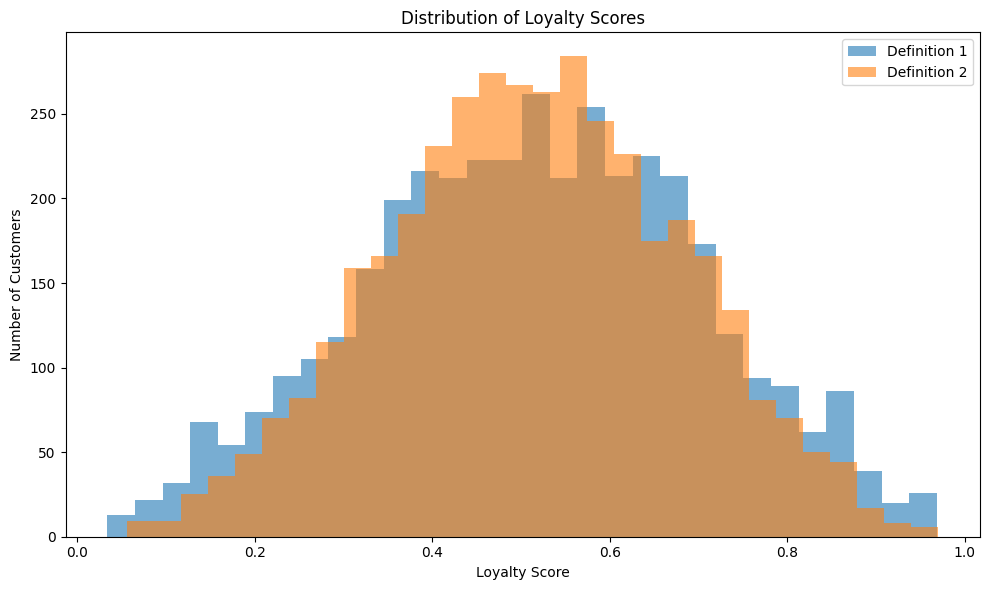

In [50]:
# =========================================================
# SCORE DISTRIBUTIONS
# =========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    customer_metrics["loyalty_score_1"],
    bins=30,
    alpha=0.6,
    label="Definition 1"
)

plt.hist(
    customer_metrics["loyalty_score_2"],
    bins=30,
    alpha=0.6,
    label="Definition 2"
)

plt.title("Distribution of Loyalty Scores")
plt.xlabel("Loyalty Score")
plt.ylabel("Number of Customers")
plt.legend()
plt.tight_layout()
plt.show()

## Distribution of purchase values

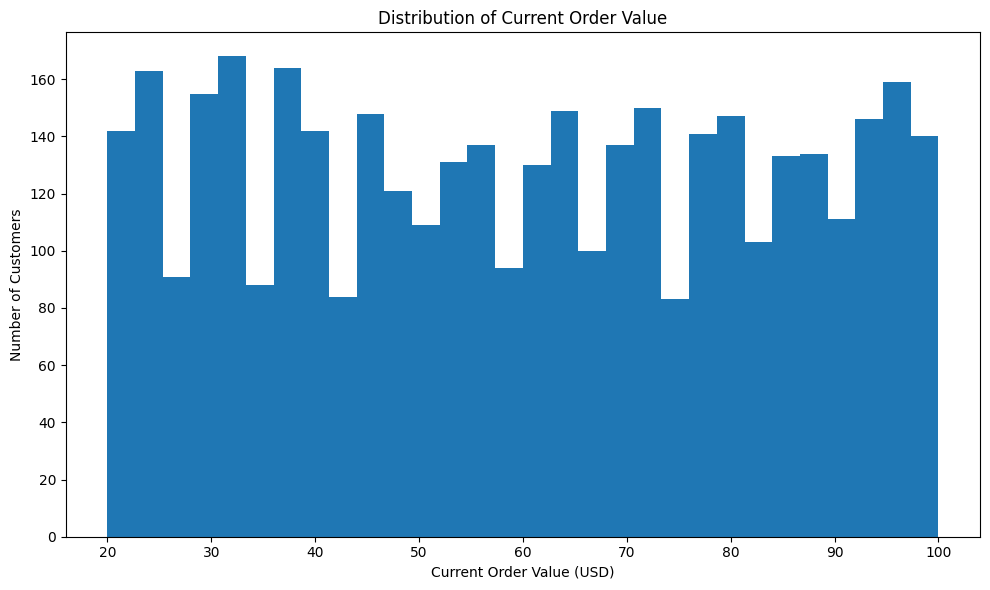

In [51]:
# =========================================================
# PURCHASE VALUE DISTRIBUTION
# =========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    customer_metrics["current_order_value"].dropna(),
    bins=30
)

plt.title("Distribution of Current Order Value")
plt.xlabel("Current Order Value (USD)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## Value by loyalty

In [52]:
# =========================================================
# CURRENT ORDER VALUE BY LOYALTY
# =========================================================

value_by_loyalty = (
    customer_metrics
    .groupby(
        "loyalty_segment_2",
        observed=True
    )["current_order_value"]
    .mean()
    .reindex(loyalty_order)
)

display(
    value_by_loyalty.to_frame(
        "average_current_order_value"
    )
)

,average_current_order_value
loyalty_segment_2,
Low Loyalty,59.07
Medium Loyalty,60.29
High Loyalty,59.93


## Correlation diagnostics

In [53]:
# =========================================================
# CORRELATION DIAGNOSTICS
# =========================================================

correlation_columns = [
    "current_order_value",
    "previous_purchases",
    "estimated_annual_frequency",
    "average_rating",
    "promo_usage",
    "subscription_flag",
    "loyalty_score_1",
    "loyalty_score_2"
]

correlation_matrix = (
    customer_metrics[correlation_columns]
    .corr(numeric_only=True)
)

display(correlation_matrix)

,current_order_value,previous_purchases,estimated_annual_frequency,average_rating,promo_usage,subscription_flag,loyalty_score_1,loyalty_score_2
current_order_value,1.00,0.01,-0.01,0.03,-0.02,-0.01,0.01,0.02
previous_purchases,0.01,1.00,0.00,0.00,0.02,0.03,0.61,0.52
estimated_annual_frequency,-0.01,0.00,1.00,-0.00,0.00,0.02,0.56,0.40
average_rating,0.03,0.00,-0.00,1.00,-0.01,-0.00,0.01,0.44
promo_usage,-0.02,0.02,0.00,-0.01,1.00,0.70,-0.51,-0.59
subscription_flag,-0.01,0.03,0.02,-0.00,0.70,1.00,-0.34,-0.40
loyalty_score_1,0.01,0.61,0.56,0.01,-0.51,-0.34,1.00,0.88
loyalty_score_2,0.02,0.52,0.40,0.44,-0.59,-0.40,0.88,1.00


## Choose preferred loyalty definition

In [54]:
# =========================================================
# PREFERRED LOYALTY DEFINITION
# =========================================================

print(
    """
Recommended evaluation criteria:

1. Clear behavioral separation between Low and High Loyalty
2. Higher purchase history for High Loyalty
3. Higher purchase cadence for High Loyalty
4. Higher satisfaction where satisfaction is included
5. Lower promotion usage among High Loyalty
6. Logical/monotonic movement across segments
7. Business interpretability

The notebook does not blindly select a definition based on
correlation with current order value because current order
value is already part of the broader customer-value concept.
"""
)


Recommended evaluation criteria:

1. Clear behavioral separation between Low and High Loyalty
2. Higher purchase history for High Loyalty
3. Higher purchase cadence for High Loyalty
4. Higher satisfaction where satisfaction is included
5. Lower promotion usage among High Loyalty
6. Logical/monotonic movement across segments
7. Business interpretability

The notebook does not blindly select a definition based on
correlation with current order value because current order
value is already part of the broader customer-value concept.



## Automated scorecard

In [55]:
# =========================================================
# LOYALTY DEFINITION SCORECARD
# =========================================================

def calculate_definition_score(segment_column):
    
    grouped = (
        customer_metrics
        .groupby(segment_column, observed=True)
        .agg(
            history=("previous_purchases", "mean"),
            frequency=("estimated_annual_frequency", "mean"),
            rating=("average_rating", "mean"),
            promo=("promo_usage", "mean")
        )
        .reindex(loyalty_order)
    )
    
    score = 0
    
    # Higher history in High Loyalty
    if grouped.loc["High Loyalty", "history"] >= grouped.loc[
        "Low Loyalty", "history"
    ]:
        score += 1
    
    # Higher frequency
    if grouped.loc["High Loyalty", "frequency"] >= grouped.loc[
        "Low Loyalty", "frequency"
    ]:
        score += 1
    
    # Higher rating
    if grouped.loc["High Loyalty", "rating"] >= grouped.loc[
        "Low Loyalty", "rating"
    ]:
        score += 1
    
    # Lower promotion usage
    if grouped.loc["High Loyalty", "promo"] <= grouped.loc[
        "Low Loyalty", "promo"
    ]:
        score += 1
    
    return score


definition_scorecard = pd.DataFrame({
    "Definition": [
        "Definition 1",
        "Definition 2"
    ],
    "Behavioral_Consistency_Score": [
        calculate_definition_score(
            "loyalty_segment_1"
        ),
        calculate_definition_score(
            "loyalty_segment_2"
        )
    ]
})

display(definition_scorecard)

,Definition,Behavioral_Consistency_Score
0,Definition 1,4
1,Definition 2,4


## Final loyalty selection

In [56]:
# =========================================================
# SELECT PREFERRED LOYALTY DEFINITION
# =========================================================

score_1 = definition_scorecard.loc[
    definition_scorecard["Definition"] == "Definition 1",
    "Behavioral_Consistency_Score"
].iloc[0]

score_2 = definition_scorecard.loc[
    definition_scorecard["Definition"] == "Definition 2",
    "Behavioral_Consistency_Score"
].iloc[0]

if score_2 > score_1:
    preferred_definition = 2
elif score_1 > score_2:
    preferred_definition = 1
else:
    # If tied, Definition 2 is preferred because it
    # incorporates satisfaction in addition to behavior.
    preferred_definition = 2

print(
    f"Preferred loyalty definition: Definition {preferred_definition}"
)

Preferred loyalty definition: Definition 2


## Final loyalty segment

In [57]:
# =========================================================
# FINAL LOYALTY SEGMENT
# =========================================================

if preferred_definition == 1:
    customer_metrics["loyalty_score"] = (
        customer_metrics["loyalty_score_1"]
    )
    
    customer_metrics["loyalty_segment"] = (
        customer_metrics["loyalty_segment_1"]
    )
    
else:
    customer_metrics["loyalty_score"] = (
        customer_metrics["loyalty_score_2"]
    )
    
    customer_metrics["loyalty_segment"] = (
        customer_metrics["loyalty_segment_2"]
    )

display(
    customer_metrics[
        [
            "customer_id",
            "loyalty_score",
            "loyalty_segment"
        ]
    ].head()
)

,customer_id,loyalty_score,loyalty_segment
0,1,0.32,Low Loyalty
1,2,0.25,Low Loyalty
2,3,0.43,Low Loyalty
3,4,0.62,High Loyalty
4,5,0.22,Low Loyalty


## Ideal customer profile

In [58]:
# =========================================================
# HIGH-LOYALTY CUSTOMER PROFILE
# =========================================================

high_loyalty = customer_metrics[
    customer_metrics["loyalty_segment"]
    == "High Loyalty"
].copy()

print(
    f"High-loyalty customers: "
    f"{len(high_loyalty):,}"
)

ideal_profile_numeric = high_loyalty[
    [
        "age",
        "current_order_value",
        "previous_purchases",
        "estimated_annual_frequency",
        "average_rating",
        "promo_usage"
    ]
].describe().T

display(ideal_profile_numeric)

High-loyalty customers: 1,300


,count,mean,std,min,25%,50%,75%,max
age,"1,300.00",44.19,15.23,18.00,31.00,44.00,57.00,70.00
current_order_value,"1,300.00",59.93,23.72,20.00,39.00,60.00,81.00,100.00
previous_purchases,"1,300.00",33.75,12.11,1.00,26.00,36.00,44.00,50.00
estimated_annual_frequency,"1,300.00",24.84,17.88,1.00,12.00,26.00,26.00,52.00
average_rating,"1,300.00",4.12,0.62,2.50,3.70,4.20,4.60,5.00
promo_usage,"1,300.00",0.12,0.32,0.00,0.00,0.00,0.00,1.00


## High-loyalty categorical profile

In [59]:
# =========================================================
# HIGH-LOYALTY CATEGORICAL PROFILE
# =========================================================

profile_columns = [
    "gender",
    "location",
    "subscription_status",
    "payment_method",
    "shipping_type",
    "preferred_category",
    "preferred_season"
]

for col in profile_columns:
    
    print("=" * 70)
    print(f"High-loyalty profile: {col}")
    print("=" * 70)
    
    counts = (
        high_loyalty[col]
        .value_counts(dropna=False)
        .to_frame("customers")
    )
    
    counts["pct"] = (
        counts["customers"]
        / len(high_loyalty)
        * 100
    )
    
    display(counts)

High-loyalty profile: gender


,customers,pct
gender,,
Male,676,52.00
Female,624,48.00


High-loyalty profile: location


,customers,pct
location,,
Alabama,40,3.08
Illinois,34,2.62
Idaho,34,2.62
Maryland,33,2.54
Pennsylvania,32,2.46
Tennessee,32,2.46
Montana,31,2.38
Minnesota,31,2.38
Georgia,30,2.31


High-loyalty profile: subscription_status


...

,customers,pct
shipping_type,,
Standard,241,18.54
Express,221,17.00
2-Day Shipping,220,16.92
Free Shipping,210,16.15
Next Day Air,205,15.77
Store Pickup,203,15.62


High-loyalty profile: preferred_category


,customers,pct
preferred_category,,
Clothing,557,42.85
Accessories,438,33.69
Footwear,200,15.38
Outerwear,105,8.08


High-loyalty profile: preferred_season


,customers,pct
preferred_season,,
Spring,346,26.62
Winter,346,26.62
Fall,305,23.46
Summer,303,23.31


## High-value / high-loyalty intersection

In [60]:
# =========================================================
# HIGH VALUE + HIGH LOYALTY
# =========================================================

high_value_high_loyalty = customer_metrics[
    (
        customer_metrics["value_segment"]
        == "High Value"
    )
    &
    (
        customer_metrics["loyalty_segment"]
        == "High Loyalty"
    )
].copy()

print(
    "High-value + high-loyalty customers:",
    len(high_value_high_loyalty)
)

display(
    high_value_high_loyalty[
        [
            "customer_id",
            "current_order_value",
            "previous_purchases",
            "estimated_annual_frequency",
            "average_rating",
            "promo_segment",
            "loyalty_segment",
            "value_segment"
        ]
    ].head(20)
)

High-value + high-loyalty customers: 432


,customer_id,current_order_value,previous_purchases,estimated_annual_frequency,average_rating,promo_segment,loyalty_segment,value_segment
3,4,90,49,52,3.50,Promo Used,High Loyalty,High Value
23,24,88,40,52,4.40,Promo Used,High Loyalty,High Value
31,32,79,45,12,4.70,Promo Used,High Loyalty,High Value
78,79,91,50,26,4.70,Promo Used,High Loyalty,High Value
94,95,76,28,52,4.60,Promo Used,High Loyalty,High Value
101,102,85,50,26,4.60,Promo Used,High Loyalty,High Value
127,128,89,26,52,4.80,Promo Used,High Loyalty,High Value
211,212,92,45,26,4.20,Promo Used,High Loyalty,High Value
241,242,88,43,26,4.10,Promo Used,High Loyalty,High Value
248,249,100,33,52,4.80,Promo Used,High Loyalty,High Value


## Commertial segment matrix
later useful for Power BI

In [61]:
# =========================================================
# VALUE x LOYALTY MATRIX
# =========================================================

value_loyalty_matrix = pd.crosstab(
    customer_metrics["value_segment"],
    customer_metrics["loyalty_segment"],
    margins=True
)

display(value_loyalty_matrix)

loyalty_segment,Low Loyalty,Medium Loyalty,High Loyalty,All
value_segment,,,,
Low Value,438,431,431,1300
Medium Value,439,427,437,1303
High Value,423,442,432,1297
All,1300,1300,1300,3900


## Segment labels

This gives your later SQL/Power BI work a clean business-facing segmentation.

In [62]:
# =========================================================
# COMMERCIAL SEGMENT LABEL
# =========================================================

segment_conditions = [
    (
        customer_metrics["value_segment"].eq("High Value")
        &
        customer_metrics["loyalty_segment"].eq("High Loyalty")
    ),
    
    (
        customer_metrics["value_segment"].eq("High Value")
        &
        customer_metrics["loyalty_segment"].eq("Medium Loyalty")
    ),
    
    (
        customer_metrics["value_segment"].eq("High Value")
        &
        customer_metrics["loyalty_segment"].eq("Low Loyalty")
    ),
    
    (
        customer_metrics["value_segment"].eq("Low Value")
        &
        customer_metrics["loyalty_segment"].eq("High Loyalty")
    )
]

segment_labels = [
    "High Value - High Loyalty",
    "High Value - Medium Loyalty",
    "High Value - Low Loyalty",
    "Low Value - High Loyalty"
]

customer_metrics["commercial_segment"] = np.select(
    segment_conditions,
    segment_labels,
    default="Other"
)

display(
    customer_metrics["commercial_segment"]
    .value_counts()
    .to_frame("customers")
)

,customers
commercial_segment,
Other,2172
High Value - Medium Loyalty,442
High Value - High Loyalty,432
Low Value - High Loyalty,431
High Value - Low Loyalty,423


## Promotional opportunity analysis

this identifies observed promotion usage, not causal discount dependency.

In [63]:
# =========================================================
# PROMOTION OPPORTUNITY ANALYSIS
# =========================================================

promo_by_segment = (
    customer_metrics
    .groupby(
        "commercial_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        promo_usage_rate=("promo_usage", "mean"),
        avg_order_value=(
            "current_order_value",
            "mean"
        ),
        avg_previous_purchases=(
            "previous_purchases",
            "mean"
        ),
        avg_rating=(
            "average_rating",
            "mean"
        )
    )
    .reset_index()
)

promo_by_segment["promo_usage_rate"] *= 100

display(
    promo_by_segment.sort_values(
        "promo_usage_rate",
        ascending=False
    )
)

,commercial_segment,customers,promo_usage_rate,avg_order_value,avg_previous_purchases,avg_rating
1,High Value - Low Loyalty,423,78.49,86.80,16.88,3.46
4,Other,2172,49.59,48.80,23.87,3.67
2,High Value - Medium Loyalty,442,38.69,87.53,24.44,3.72
3,Low Value - High Loyalty,431,12.06,32.34,33.02,4.08
0,High Value - High Loyalty,432,10.42,87.37,34.39,4.14


## Identify potential promotion-risk segment

In [64]:
# =========================================================
# POTENTIAL PROMOTION-RISK SEGMENT
# =========================================================

promotion_risk = (
    customer_metrics
    .groupby(
        "commercial_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        promo_usage_rate=("promo_usage", "mean"),
        avg_order_value=(
            "current_order_value",
            "mean"
        ),
        avg_previous_purchases=(
            "previous_purchases",
            "mean"
        )
    )
    .reset_index()
)

promotion_risk["promo_usage_rate"] *= 100

promotion_risk = promotion_risk.sort_values(
    [
        "promo_usage_rate",
        "avg_previous_purchases"
    ],
    ascending=[False, True]
)

display(promotion_risk)

,commercial_segment,customers,promo_usage_rate,avg_order_value,avg_previous_purchases
1,High Value - Low Loyalty,423,78.49,86.80,16.88
4,Other,2172,49.59,48.80,23.87
2,High Value - Medium Loyalty,442,38.69,87.53,24.44
3,Low Value - High Loyalty,431,12.06,32.34,33.02
0,High Value - High Loyalty,432,10.42,87.37,34.39


## Data quality summary

In [65]:
# =========================================================
# FINAL DATA QUALITY SUMMARY
# =========================================================

quality_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Unique Customers",
        "Duplicate Customer Rows",
        "Exact Duplicate Rows",
        "Missing Review Ratings",
        "Promo/Discount Agreement",
        "Unmapped Frequency Values"
    ],
    "Value": [
        len(df),
        df["customer_id"].nunique(),
        df["customer_id"].duplicated().sum(),
        df.duplicated().sum(),
        df["rating_missing"].sum(),
        promo_discount_match_rate,
        len(unmapped_frequency)
    ]
})

display(quality_summary)

,Metric,Value
0,Rows,"3,900.00"
1,Unique Customers,"3,900.00"
2,Duplicate Customer Rows,0.00
3,Exact Duplicate Rows,0.00
4,Missing Review Ratings,37.00
5,Promo/Discount Agreement,1.00
6,Unmapped Frequency Values,0.00


## Final analytical dataset inspection

In [66]:
# =========================================================
# FINAL CUSTOMER ANALYTICAL TABLE
# =========================================================

final_columns = [
    # ID
    "customer_id",
    
    # Customer profile
    "age",
    "gender",
    "location",
    
    # Purchase/value
    "current_order_value",
    "value_score",
    "value_segment",
    
    # Historical behavior
    "previous_purchases",
    "known_purchase_count",
    "estimated_annual_frequency",
    "frequency_label",
    
    # Promotion
    "promo_usage",
    "promo_segment",
    "promo_independence_score",
    
    # Satisfaction
    "average_rating",
    "rating_missing",
    "satisfaction_band",
    
    # Subscription
    "subscription_status",
    "subscription_flag",
    
    # Preferences
    "preferred_category",
    "preferred_season",
    
    # Loyalty
    "history_score",
    "frequency_score",
    "satisfaction_score",
    "loyalty_score_1",
    "loyalty_segment_1",
    "loyalty_score_2",
    "loyalty_segment_2",
    "loyalty_score",
    "loyalty_segment",
    
    # Commercial
    "commercial_segment"
]

final_customer_metrics = customer_metrics[
    final_columns
].copy()

display(
    final_customer_metrics.head(10)
)

,customer_id,age,gender,location,current_order_value,value_score,value_segment,previous_purchases,known_purchase_count,estimated_annual_frequency,frequency_label,promo_usage,promo_segment,promo_independence_score,average_rating,rating_missing,satisfaction_band,subscription_status,subscription_flag,preferred_category,preferred_season,history_score,frequency_score,satisfaction_score,loyalty_score_1,loyalty_segment_1,loyalty_score_2,loyalty_segment_2,loyalty_score,loyalty_segment,commercial_segment
0,1,55,Male,Kentucky,53,0.42,Medium Value,14,15,26,Fortnightly,1,Promo Used,0,3.10,0,Moderate,Yes,1,Clothing,Winter,0.27,0.72,0.24,0.40,Low Loyalty,0.32,Low Loyalty,0.32,Low Loyalty,Other
1,2,19,Male,Maine,64,0.55,Medium Value,2,3,26,Fortnightly,1,Promo Used,0,3.10,0,Moderate,Yes,1,Clothing,Winter,0.03,0.72,0.24,0.30,Low Loyalty,0.25,Low Loyalty,0.25,Low Loyalty,Other
2,3,50,Male,Massachusetts,73,0.66,Medium Value,23,24,52,Weekly,1,Promo Used,0,3.10,0,Moderate,Yes,1,Clothing,Spring,0.45,0.93,0.24,0.55,Medium Loyalty,0.43,Low Loyalty,0.43,Low Loyalty,Other
3,4,21,Male,Rhode Island,90,0.87,High Value,49,50,52,Weekly,1,Promo Used,0,3.50,0,Moderate,Yes,1,Footwear,Spring,0.97,0.93,0.40,0.76,High Loyalty,0.62,High Loyalty,0.62,High Loyalty,High Value - High Loyalty
4,5,45,Male,Oregon,49,0.37,Medium Value,31,32,1,Annually,1,Promo Used,0,2.70,0,Low,Yes,1,Clothing,Spring,0.62,0.07,0.08,0.28,Low Loyalty,0.22,Low Loyalty,0.22,Low Loyalty,Other
5,6,46,Male,Wyoming,20,0.01,Low Value,14,15,52,Weekly,1,Promo Used,0,2.90,0,Low,Yes,1,Footwear,Summer,0.27,0.93,0.15,0.48,Medium Loyalty,0.35,Low Loyalty,0.35,Low Loyalty,Other
6,7,63,Male,Montana,85,0.81,High Value,49,50,4,Quarterly,1,Promo Used,0,3.20,0,Moderate,Yes,1,Clothing,Fall,0.97,0.29,0.28,0.51,Medium Loyalty,0.43,Low Loyalty,0.43,Low Loyalty,High Value - Low Loyalty
7,8,27,Male,Louisiana,34,0.19,Low Value,19,20,52,Weekly,1,Promo Used,0,3.20,0,Moderate,Yes,1,Clothing,Winter,0.37,0.93,0.28,0.52,Medium Loyalty,0.41,Low Loyalty,0.41,Low Loyalty,Other
8,9,26,Male,West Virginia,97,0.96,High Value,8,9,1,Annually,1,Promo Used,0,2.60,0,Low,Yes,1,Outerwear,Summer,0.16,0.07,0.04,0.09,Low Loyalty,0.07,Low Loyalty,0.07,Low Loyalty,High Value - Low Loyalty
9,10,57,Male,Missouri,31,0.15,Low Value,4,5,4,Quarterly,1,Promo Used,0,4.80,0,High,Yes,1,Accessories,Spring,0.07,0.29,0.92,0.15,Low Loyalty,0.33,Low Loyalty,0.33,Low Loyalty,Other


## Final sanity checks

In [68]:
# =========================================================
# FINAL SANITY CHECKS
# =========================================================

checks = {
    "Unique customer IDs": (
        final_customer_metrics["customer_id"].nunique()
        == len(final_customer_metrics)
    ),
    
    "No negative order values": (
        final_customer_metrics["current_order_value"]
        .dropna()
        .ge(0)
        .all()
    ),
    
    "Previous purchases non-negative": (
        final_customer_metrics["previous_purchases"]
        .dropna()
        .ge(0)
        .all()
    ),
    
    "Ratings within 1-5": (
        final_customer_metrics["average_rating"]
        .dropna()
        .between(1, 5)
        .all()
    ),
    
    "Loyalty scores within 0-1": (
        final_customer_metrics["loyalty_score"]
        .dropna()
        .between(0, 1)
        .all()
    )
}

sanity_check = pd.DataFrame(
    list(checks.items()),
    columns=["Check", "Passed"]
)

display(sanity_check)

if sanity_check["Passed"].all():
    print("ALL SANITY CHECKS PASSED.")
else:
    print("WARNING: One or more sanity checks failed.")

,Check,Passed
0,Unique customer IDs,True
1,No negative order values,True
2,Previous purchases non-negative,True
3,Ratings within 1-5,True
4,Loyalty scores within 0-1,True


ALL SANITY CHECKS PASSED.


## Export clean customer table

In [69]:
# =========================================================
# EXPORT FINAL CUSTOMER ANALYTICAL TABLE
# =========================================================

customer_output_path = (
    OUTPUT_DIR / "customer_analytical_metrics.csv"
)

final_customer_metrics.to_csv(
    customer_output_path,
    index=False
)

print(
    "Saved:",
    customer_output_path.resolve()
)

Saved: C:\Users\VARSHIKA MUTHA\Desktop\project_2\output\customer_analytical_metrics.csv


## Export loyalty comparison

In [70]:
# =========================================================
# EXPORT LOYALTY COMPARISON
# =========================================================

loyalty_comparison_path = (
    OUTPUT_DIR / "loyalty_definition_comparison.csv"
)

comparison_export = pd.concat(
    [
        definition_1_summary.assign(
            definition="Definition 1"
        ),
        definition_2_summary.assign(
            definition="Definition 2"
        )
    ],
    ignore_index=True
)

comparison_export.to_csv(
    loyalty_comparison_path,
    index=False
)

print(
    "Saved:",
    loyalty_comparison_path.resolve()
)

Saved: C:\Users\VARSHIKA MUTHA\Desktop\project_2\output\loyalty_definition_comparison.csv


## Export commercial segment summary

In [71]:
# =========================================================
# EXPORT COMMERCIAL SEGMENT SUMMARY
# =========================================================

segment_summary = (
    customer_metrics
    .groupby(
        "commercial_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        avg_order_value=(
            "current_order_value",
            "mean"
        ),
        avg_previous_purchases=(
            "previous_purchases",
            "mean"
        ),
        avg_annual_frequency=(
            "estimated_annual_frequency",
            "mean"
        ),
        avg_rating=(
            "average_rating",
            "mean"
        ),
        promo_usage_rate=(
            "promo_usage",
            "mean"
        ),
        subscription_rate=(
            "subscription_flag",
            "mean"
        )
    )
    .reset_index()
)

segment_summary["promo_usage_rate"] *= 100
segment_summary["subscription_rate"] *= 100

segment_output_path = (
    OUTPUT_DIR / "commercial_segment_summary.csv"
)

segment_summary.to_csv(
    segment_output_path,
    index=False
)

display(segment_summary)

print(
    "Saved:",
    segment_output_path.resolve()
)

,commercial_segment,customers,avg_order_value,avg_previous_purchases,avg_annual_frequency,avg_rating,promo_usage_rate,subscription_rate
0,High Value - High Loyalty,432,87.37,34.39,23.94,4.14,10.42,7.87
1,High Value - Low Loyalty,423,86.80,16.88,10.55,3.46,78.49,47.75
2,High Value - Medium Loyalty,442,87.53,24.44,16.88,3.72,38.69,25.79
3,Low Value - High Loyalty,431,32.34,33.02,26.01,4.08,12.06,8.35
4,Other,2172,48.80,23.87,15.96,3.67,49.59,30.71


Saved: C:\Users\VARSHIKA MUTHA\Desktop\project_2\output\commercial_segment_summary.csv


## Export commercial segment summary

In [72]:
# =========================================================
# EXPORT COMMERCIAL SEGMENT SUMMARY
# =========================================================

segment_summary = (
    customer_metrics
    .groupby(
        "commercial_segment",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        avg_order_value=(
            "current_order_value",
            "mean"
        ),
        avg_previous_purchases=(
            "previous_purchases",
            "mean"
        ),
        avg_annual_frequency=(
            "estimated_annual_frequency",
            "mean"
        ),
        avg_rating=(
            "average_rating",
            "mean"
        ),
        promo_usage_rate=(
            "promo_usage",
            "mean"
        ),
        subscription_rate=(
            "subscription_flag",
            "mean"
        )
    )
    .reset_index()
)

segment_summary["promo_usage_rate"] *= 100
segment_summary["subscription_rate"] *= 100

segment_output_path = (
    OUTPUT_DIR / "commercial_segment_summary.csv"
)

segment_summary.to_csv(
    segment_output_path,
    index=False
)

display(segment_summary)

print(
    "Saved:",
    segment_output_path.resolve()
)

,commercial_segment,customers,avg_order_value,avg_previous_purchases,avg_annual_frequency,avg_rating,promo_usage_rate,subscription_rate
0,High Value - High Loyalty,432,87.37,34.39,23.94,4.14,10.42,7.87
1,High Value - Low Loyalty,423,86.80,16.88,10.55,3.46,78.49,47.75
2,High Value - Medium Loyalty,442,87.53,24.44,16.88,3.72,38.69,25.79
3,Low Value - High Loyalty,431,32.34,33.02,26.01,4.08,12.06,8.35
4,Other,2172,48.80,23.87,15.96,3.67,49.59,30.71


Saved: C:\Users\VARSHIKA MUTHA\Desktop\project_2\output\commercial_segment_summary.csv


## Export data dictionary

This will be useful for SQL and Power BI.

In [73]:
# =========================================================
# DATA DICTIONARY
# =========================================================

data_dictionary = pd.DataFrame({
    "column": final_customer_metrics.columns,
    "definition": [
        "Unique customer identifier",
        "Customer age",
        "Customer gender",
        "Customer location",
        "Observed/current purchase amount in USD",
        "Percentile rank of current order value",
        "Relative current-order-value segment",
        "Number of previous purchases reported in the dataset",
        "Previous purchases plus current observed purchase",
        "Estimated annual purchase cadence based on stated frequency category",
        "Original purchase-frequency category",
        "Observed use of promotion/discount",
        "Observed promotion-use category",
        "Independence from observed promotion usage",
        "Average observed review rating",
        "Flag indicating missing review information",
        "Rating band",
        "Subscription status",
        "Binary subscription indicator",
        "Most frequently observed category; ties retained",
        "Most frequently observed season; ties retained",
        "Percentile score for previous-purchase history",
        "Percentile score for estimated purchase cadence",
        "Percentile score for satisfaction",
        "Behavioral loyalty score",
        "Behavioral loyalty segment",
        "Behavior + satisfaction loyalty score",
        "Behavior + satisfaction loyalty segment",
        "Selected loyalty score",
        "Selected loyalty segment",
        "Combined value and loyalty commercial segment"
    ]
})

dictionary_path = (
    OUTPUT_DIR / "customer_data_dictionary.csv"
)

data_dictionary.to_csv(
    dictionary_path,
    index=False
)

display(data_dictionary)

print(
    "Saved:",
    dictionary_path.resolve()
)

,column,definition
0,customer_id,Unique customer identifier
1,age,Customer age
2,gender,Customer gender
3,location,Customer location
4,current_order_value,Observed/current purchase amount in USD
5,value_score,Percentile rank of current order value
6,value_segment,Relative current-order-value segment
7,previous_purchases,Number of previous purchases reported in the d...
8,known_purchase_count,Previous purchases plus current observed purchase
9,estimated_annual_frequency,Estimated annual purchase cadence based on sta...


Saved: C:\Users\VARSHIKA MUTHA\Desktop\project_2\output\customer_data_dictionary.csv


## Final executive summary

In [74]:
# =========================================================
# EXECUTIVE SUMMARY
# =========================================================

print("=" * 80)
print("CUSTOMER ANALYSIS - EXECUTIVE SUMMARY")
print("=" * 80)

print(f"\nCustomers analyzed: {len(customer_metrics):,}")

print(
    f"Preferred loyalty definition: "
    f"Definition {preferred_definition}"
)

print(
    "\nHigh-loyalty customers:",
    (
        customer_metrics["loyalty_segment"]
        .eq("High Loyalty")
        .sum()
    )
)

print(
    "High-value customers:",
    (
        customer_metrics["value_segment"]
        .eq("High Value")
        .sum()
    )
)

print(
    "High-value + high-loyalty customers:",
    len(high_value_high_loyalty)
)

print(
    "\nHighest promotion-use commercial segments:"
)

display(
    promotion_risk.head(5)
)

print(
    "\nIMPORTANT LIMITATIONS:"
)

print(
    """
1. Dataset is customer-level rather than transaction-level.
2. Current order value is not lifetime spend.
3. Estimated annual frequency is derived from stated cadence,
   not transaction timestamps.
4. Promo usage is observed behavior, not proven causal dependency.
5. Churn cannot be measured because there are no timestamps/churn labels.
"""
)

CUSTOMER ANALYSIS - EXECUTIVE SUMMARY

Customers analyzed: 3,900
Preferred loyalty definition: Definition 2

High-loyalty customers: 1300
High-value customers: 1297
High-value + high-loyalty customers: 432

Highest promotion-use commercial segments:


,commercial_segment,customers,promo_usage_rate,avg_order_value,avg_previous_purchases
1,High Value - Low Loyalty,423,78.49,86.80,16.88
4,Other,2172,49.59,48.80,23.87
2,High Value - Medium Loyalty,442,38.69,87.53,24.44
3,Low Value - High Loyalty,431,12.06,32.34,33.02
0,High Value - High Loyalty,432,10.42,87.37,34.39



IMPORTANT LIMITATIONS:

1. Dataset is customer-level rather than transaction-level.
2. Current order value is not lifetime spend.
3. Estimated annual frequency is derived from stated cadence,
   not transaction timestamps.
4. Promo usage is observed behavior, not proven causal dependency.
5. Churn cannot be measured because there are no timestamps/churn labels.



# Conclusion

The resulting customer-level analytical dataset is now suitable for the next project stages.

## What has been established

### Data
- Customer-level grain has been explicitly established.
- Duplicate and missing-value issues have been assessed.
- Numeric ranges have been validated.
- Promo and discount variables have been tested for redundancy.

### Behavioral features
- Previous purchase history is retained as historical depth.
- Purchase-frequency categories are translated into estimated annual cadence.
- Current order value is kept separate from historical behavior.
- Review missingness is preserved.
- Promotion usage is treated as observed usage rather than proven dependency.

### Loyalty
Two competing loyalty definitions were constructed:

**Definition 1**
- Purchase history
- Estimated purchase cadence
- Promotion independence

**Definition 2**
- Purchase history
- Estimated purchase cadence
- Satisfaction
- Promotion independence

The definitions are compared using behavioral consistency rather than simply correlating the score with a variable already included in the score.

### Commercial segmentation
Customers are classified by:
- Current observed value
- Loyalty
- Promotion usage
- Combined commercial segment

## Downstream use

The exported files can now be used for:

1. SQL business-question analysis
2. Power BI dashboard construction
3. Customer segment profiling
4. Promotional strategy
5. Loyalty recommendations
6. Final consulting playbook